# GCsp Fisher: minimal matched CLASS HMcode 2020 vs SYREN-NEW

Both the direct power-spectrum checks and the Fisher runs use CosmicFishPie's YAML-backed `cosmo_functions` interface. The profiles reproduce the upstream SYREN-NEW neutrino convention: three degenerate massive neutrinos, `N_ur=0.00641`, `m_ncdm=mnu/3`, and `Omega_cdm = Omegam - Omegab - mnu/(93.14 h^2)`.

CLASS uses HMcode 2020 while SYREN-NEW uses its native nonlinear emulator. This is an operational comparison, not a CLASS+EE2 validation.

In [23]:
from pathlib import Path
import os

os.environ["OMP_NUM_THREADS"] = "8"
import matplotlib.pyplot as plt
import numpy as np

import cosmicfishpie
from cosmicfishpie.fishermatrix.cosmicfish import FisherMatrix
from cosmicfishpie.configs.context import build_analysis_context
from cosmicfishpie.cosmology.cosmology import cosmo_functions

repo_root = Path.cwd().resolve()
if not (repo_root / 'cosmicfishpie').is_dir():
    repo_root = repo_root.parent
package_root = Path(cosmicfishpie.__file__).resolve().parents[1]
if package_root != repo_root:
    raise RuntimeError(
        'Kernel/package mismatch: notebook profiles resolve from '
        f'{repo_root}, but cosmicfishpie imports from {package_root}. '
        'Restart with the kernel from the notebook checkout before running this notebook.'
    )

class_yaml = repo_root / 'cosmicfishpie/configs/default_boltzmann_yaml_files/class/syren_new_minimal_matched.yaml'
symbolic_yaml = repo_root / 'cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/syren_new_minimal_matched.yaml'
results_dir = repo_root / 'results/syren_new_class_hmcode2020_gcsp_minimal_matched'
results_dir.mkdir(parents=True, exist_ok=True)

assert class_yaml.is_file() and symbolic_yaml.is_file()
print('CLASS profile:', class_yaml)
print('SYREN-NEW profile:', symbolic_yaml)
print('Fisher outputs:', results_dir)

CLASS profile: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/cosmicfishpie/configs/default_boltzmann_yaml_files/class/syren_new_minimal_matched.yaml
SYREN-NEW profile: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/cosmicfishpie/configs/default_boltzmann_yaml_files/symbolic/syren_new_minimal_matched.yaml
Fisher outputs: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/syren_new_class_hmcode2020_gcsp_minimal_matched


## Matched solver contract

`class/syren_new_minimal_matched.yaml` opts into the explicit `three_degenerate` CLASS translation mode. It requests `mPk,mTk` (the transfer output is required by CosmicFishPie), HMcode 2020, `z_max_pk=3`, `P_k_max_1/Mpc=3`, three massive neutrinos, `N_ur=0.00641`, and the direct-example background settings. `symbolic/syren_new_minimal_matched.yaml` has only the SYREN-NEW selector plus a common `0 <= z <= 3`, `10^-3 <= k <= 3 h/Mpc` interpolation grid.

`10^9As` is passed unchanged to SYREN-NEW and converted once to CLASS `A_s = 10^9As * 10^-9`. `Neff` is intentionally excluded: it is not a SYREN-NEW input and would break the common three-degenerate-neutrino contract.

In [24]:
FIDUCIAL_LCDM = {
    '10^9As': 2.1,
    'Omegam': 0.32,
    'Omegab': 0.05,
    'h': 0.67,
    'ns': 0.96,
    'mnu': 0.06,
}
FIDUCIAL_W0WA = {**FIDUCIAL_LCDM, 'w0': -1.0, 'wa': 0.0}

# CosmicFishPie uses relative steps for non-zero parameters and absolute steps at zero.
LCDM_FREEPARS = {parameter: 0.01 for parameter in FIDUCIAL_LCDM if parameter is not 'mnu'}
W0WA_FREEPARS = {**LCDM_FREEPARS, 'w0': 0.01, 'wa': 0.05}

K_HMPC = np.logspace(np.log10(9.0e-3), np.log10(3.0), 200)
Z_RESPONSE = 1.0

{
    'lcdm_parameters': list(LCDM_FREEPARS),
    'w0wa_parameters': list(W0WA_FREEPARS),
    'fisher_steps': {'LCDM': LCDM_FREEPARS, 'w0waCDM': W0WA_FREEPARS},
}

<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
<>:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
/tmp/ipykernel_122397/4028182485.py:12: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  LCDM_FREEPARS = {parameter: 0.01 for parameter in FIDUCIAL_LCDM if parameter is not 'mnu'}


{'lcdm_parameters': ['10^9As', 'Omegam', 'Omegab', 'h', 'ns'],
 'w0wa_parameters': ['10^9As', 'Omegam', 'Omegab', 'h', 'ns', 'w0', 'wa'],
 'fisher_steps': {'LCDM': {'10^9As': 0.01,
   'Omegam': 0.01,
   'Omegab': 0.01,
   'h': 0.01,
   'ns': 0.01},
  'w0waCDM': {'10^9As': 0.01,
   'Omegam': 0.01,
   'Omegab': 0.01,
   'h': 0.01,
   'ns': 0.01,
   'w0': 0.01,
   'wa': 0.05}}}

## Direct matched spectra

Both curves are evaluated through the same CosmicFishPie `cosmo_functions.Pmm` interface used by the forecasts. The only backend-specific choice is the minimal YAML profile.

{'max_abs_fractional_difference': 0.0030694596882555603,
 'figure': <Figure size 700x600 with 2 Axes>}

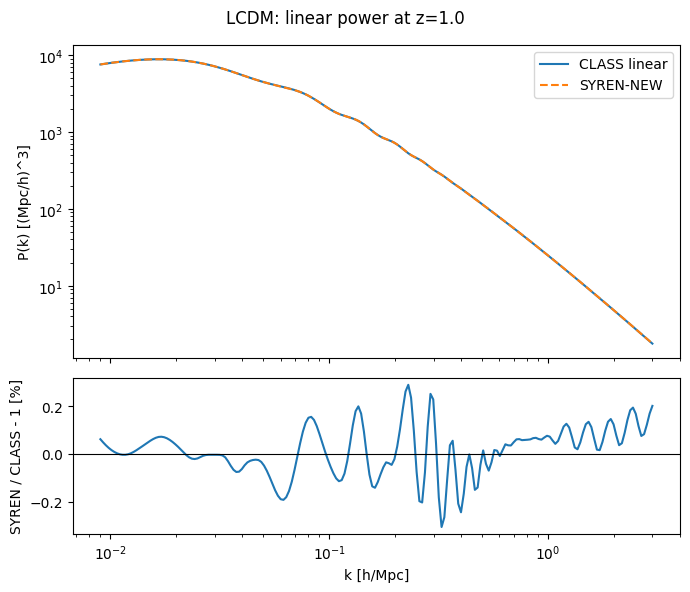

In [25]:
def build_unified_cosmology(code, parameters, cosmo_model):
    yaml_key, yaml_path = (
        ('class_config_yaml', class_yaml)
        if code == 'class'
        else ('symbolic_config_yaml', symbolic_yaml)
    )
    configuration = build_analysis_context(
        options={
            'code': code,
            yaml_key: str(yaml_path),
            'cosmo_model': cosmo_model,
            'nonlinear': True,
            'feedback': 0,
            'specs_dir': str(repo_root / 'cosmicfishpie/configs/default_survey_specifications') + '/',
        },
        observables=['GCsp'],
        freepars={},
        fiducialpars=parameters,
        survey_name='Euclid',
        cosmo_model=cosmo_model,
    )
    return cosmo_functions(parameters, configuration=configuration)


def unified_power(code, k_hmpc, parameters, z, nonlinear=False, cosmo_model='LCDM'):
    cosmology = build_unified_cosmology(code, parameters, cosmo_model)
    h = parameters['h']
    return cosmology.Pmm(z, k_hmpc * h, nonlinear=nonlinear) * h**3


def plot_power_comparison(parameters, cosmo_model, nonlinear=False):
    p_class = unified_power('class', K_HMPC, parameters, Z_RESPONSE, nonlinear, cosmo_model)
    p_syren = unified_power('symbolic', K_HMPC, parameters, Z_RESPONSE, nonlinear, cosmo_model)
    residual = p_syren / p_class - 1.0
    label = 'nonlinear' if nonlinear else 'linear'
    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, height_ratios=[2, 1])
    axes[0].loglog(K_HMPC, p_class, label='CLASS HMcode 2020' if nonlinear else 'CLASS linear')
    axes[0].loglog(K_HMPC, p_syren, '--', label='SYREN-NEW')
    axes[0].set_ylabel('P(k) [(Mpc/h)^3]')
    axes[0].legend()
    axes[1].semilogx(K_HMPC, 100.0 * residual)
    axes[1].axhline(0.0, color='black', linewidth=0.8)
    axes[1].set(xlabel='k [h/Mpc]', ylabel='SYREN / CLASS - 1 [%]')
    fig.suptitle(f'{cosmo_model}: {label} power at z={Z_RESPONSE}')
    fig.tight_layout()
    return {'max_abs_fractional_difference': float(np.max(np.abs(residual))), 'figure': fig}

plot_power_comparison(FIDUCIAL_LCDM, 'LCDM', nonlinear=False)

{'max_abs_fractional_difference': 0.031107752720683335,
 'figure': <Figure size 700x600 with 2 Axes>}

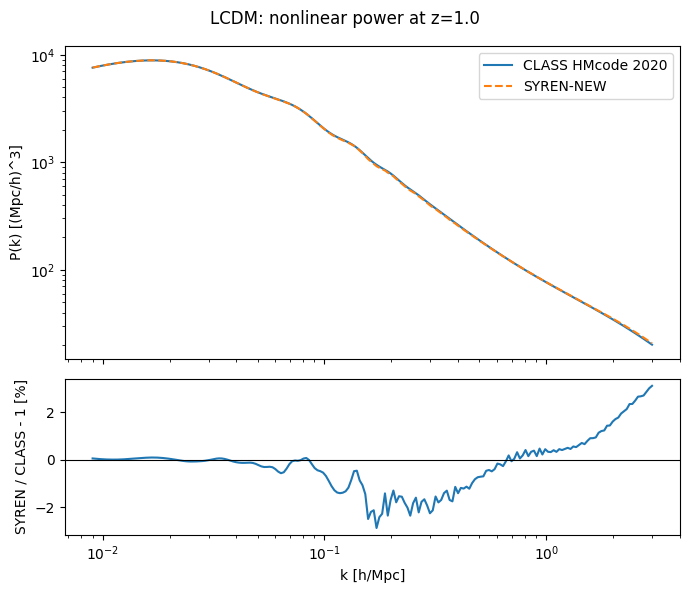

In [26]:
plot_power_comparison(FIDUCIAL_LCDM, 'LCDM', nonlinear=True)

## Linear and nonlinear parameter responses

Before interpreting contours, compare the derivatives of the GCsp observable computed by `cosmicfishpie.fishermatrix.derivatives`. This evaluates every shared LCDM input (`10^9As`, `Omegam`, `Omegab`, `h`, `ns`, `mnu`) and adds `w0`, `wa` for w0waCDM.

## Matched GCsp Fishers

Run each model separately. Both sides receive identical fiducials, finite-difference steps, survey specifications, and minimal solver profiles. No `Neff` derivative is included because it is not common to the two providers.

In [9]:
def run_gcsp_fisher_pair(cosmo_model, fiducial, freepars):
    common_options = {
        'accuracy': 1,
        'derivatives': '3PT',
        'feedback': 1,
        'nonlinear': False,
        'survey_name': 'Euclid',
        'survey_name_photo': False,
        'survey_name_spectro': 'Euclid-Spectroscopic-ISTF-Pessimistic',
        'specs_dir': str(repo_root / 'cosmicfishpie/configs/default_survey_specifications') + '/',
        'cosmo_model': cosmo_model,
        'results_dir': str(results_dir) + '/',
    }
    runs = {
        'CLASS HMcode 2020': ('class', 'class_config_yaml', class_yaml, 'minimal_matched_class_hmcode2020'),
        'SYREN-NEW': ('symbolic', 'symbolic_config_yaml', symbolic_yaml, 'minimal_matched_syren_new'),
    }
    completed = {}
    for label, (code, yaml_key, yaml_path, outroot) in runs.items():
        options = {**common_options, 'code': code, yaml_key: str(yaml_path), 'outroot': f'{cosmo_model}_{outroot}'}
        calculation = FisherMatrix(
            fiducialpars=fiducial,
            freepars=freepars,
            options=options,
            observables=['GCsp'],
            cosmoModel=cosmo_model,
            surveyName='Euclid',
        )
        fisher = calculation.compute()
        completed[label] = {
            'file_name': Path(fisher.file_name),
            'derivatives': calculation.derivs_dict,
            'k_mesh': calculation.Pk_kmesh,
            'mu_mesh': calculation.Pk_mumesh,
            'z_bins': calculation.fish_z_arr,
            'h': calculation.fiducialcosmopars['h'],
        }
    return completed


# Execute these one at a time. They are intentionally not run by this notebook definition.
lcdm_fisher_runs = run_gcsp_fisher_pair('LCDM', FIDUCIAL_LCDM, LCDM_FREEPARS)
# w0wa_fisher_runs = run_gcsp_fisher_pair('w0waCDM', FIDUCIAL_W0WA, W0WA_FREEPARS)

****************************************************************
   _____               _     _____     __  
  / ___/__  ___ __ _  (_)___/ __(_)__ / /  
 / /__/ _ \(_-</  ' \/ / __/ _// (_-</ _ \ 
 \___/\___/___/_/_/_/_/\__/_/ /_/___/_//_/ 

****************************************************************
 This is the new Python version of the CosmicFish code.
****************************************************************

  -> Survey loaded:  Euclid-Spectroscopic-ISTF-Pessimistic

  -> Computing cosmology at the fiducial point

  ---> Cosmological functions obtained in:   1.04 s

In class: FisherMatrix  ----> Computing spectroscopic P(k) Fisher matrix for ['GCsp']
Computing derivatives of Galaxy Clustering Spectro
>> Computing Derivs >>

  +++ Computing derivative on 10^9As

In class: derivatives  Derivative on 10^9As done! in :  2.10 s

  +++ Computing derivative on Omegam

In class: derivatives  Derivative on Omegam done! in :  2.21 s

  +++ Computing derivative on Omegab

In clas

## All-parameter derivative canvas

This intentionally busy view overlays every GCsp observable derivative on one canvas. It reads the `derivs_dict` generated by CosmicFishPie's common `derivatives.py` engine, not a notebook-local finite-difference function. A parameter has the same color for both providers; CLASS is solid and SYREN-NEW is dashed.

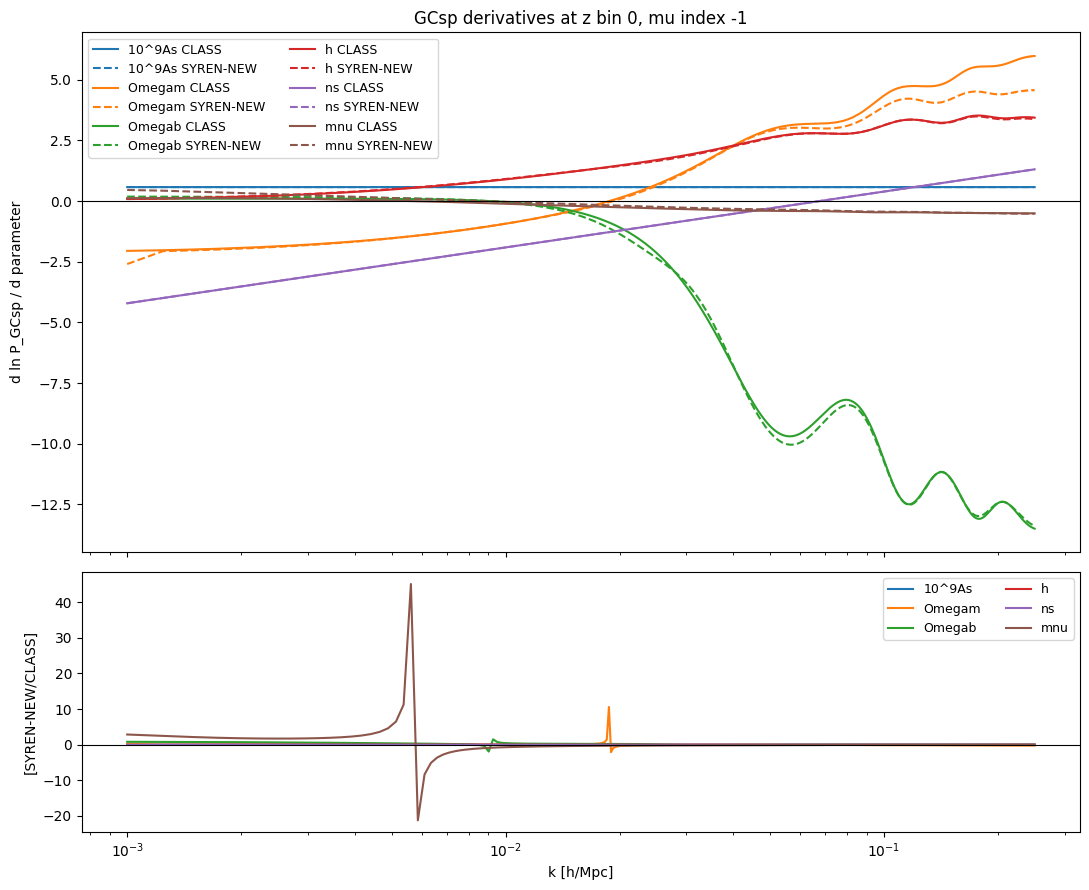

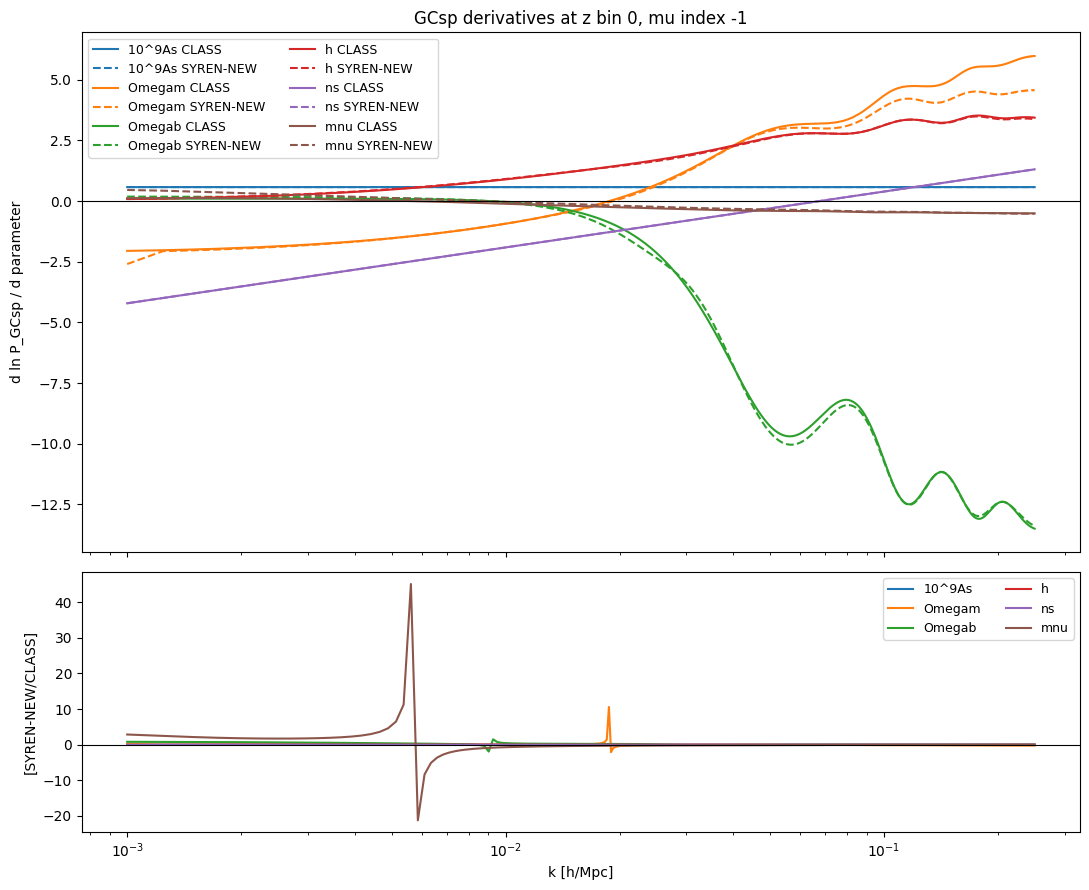

In [13]:
def plot_all_fisher_derivatives(fisher_runs, freepars, z_index=0, mu_index=-1):
    class_run = fisher_runs['CLASS HMcode 2020']
    syren_run = fisher_runs['SYREN-NEW']
    k_hmpc = class_run['k_mesh'][mu_index] / class_run['h']
    colors = plt.get_cmap('tab10').colors
    fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True, height_ratios=[2, 1])
    eps=0.1
    for color, parameter in zip(colors, freepars):
        class_derivative = class_run['derivatives'][parameter][z_index][mu_index]
        syren_derivative = syren_run['derivatives'][parameter][z_index][mu_index]
        axes[0].semilogx(k_hmpc, class_derivative+eps, color=color, linestyle='-', label=f'{parameter} CLASS')
        axes[0].semilogx(k_hmpc, syren_derivative+eps, color=color, linestyle='--', label=f'{parameter} SYREN-NEW')
        axes[1].semilogx(k_hmpc, ((syren_derivative+eps)/(class_derivative+eps) -1), color=color, label=parameter)

    axes[0].axhline(0.0, color='black', linewidth=0.8)
    axes[0].set_ylabel('d ln P_GCsp / d parameter')
    axes[0].set_title(f'GCsp derivatives at z bin {z_index}, mu index {mu_index}')
    axes[0].legend(ncol=2, fontsize=9, loc='best')
    axes[1].axhline(0.0, color='black', linewidth=0.8)
    axes[1].set(xlabel='k [h/Mpc]', ylabel='[SYREN-NEW/CLASS]')
    axes[1].legend(ncol=2, fontsize=9, loc='best')
    fig.tight_layout()
    return fig


# Run after run_gcsp_fisher_pair returns a derivative-bearing run dictionary.
plot_all_fisher_derivatives(lcdm_fisher_runs, LCDM_FREEPARS)
# plot_all_fisher_derivatives(w0wa_fisher_runs, W0WA_FREEPARS)

## Parameter-by-parameter constraints and contours

After a pair completes, use CosmicFishPie's `fisher_matrix` reader and ChainConsumer-backed `fishconsumer` triangle plotter. The marginal-error panel is built directly from the same library reader, avoiding the historical `compare_errors` Boolean-index ambiguity.

Plot saved to: /home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/syren_new_class_hmcode2020_gcsp_minimal_matched/plots/LCDM_minimal_matched_contours.pdf


{'marginal_errors': PosixPath('/home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/syren_new_class_hmcode2020_gcsp_minimal_matched/plots/LCDM_minimal_matched_marginal_errors.pdf'),
 'contours': PosixPath('/home/casas/Cosmo/dev-cosmicfishpie/cosmicfishpie-symbolic_overhaul/results/syren_new_class_hmcode2020_gcsp_minimal_matched/plots/LCDM_minimal_matched_contours.pdf')}

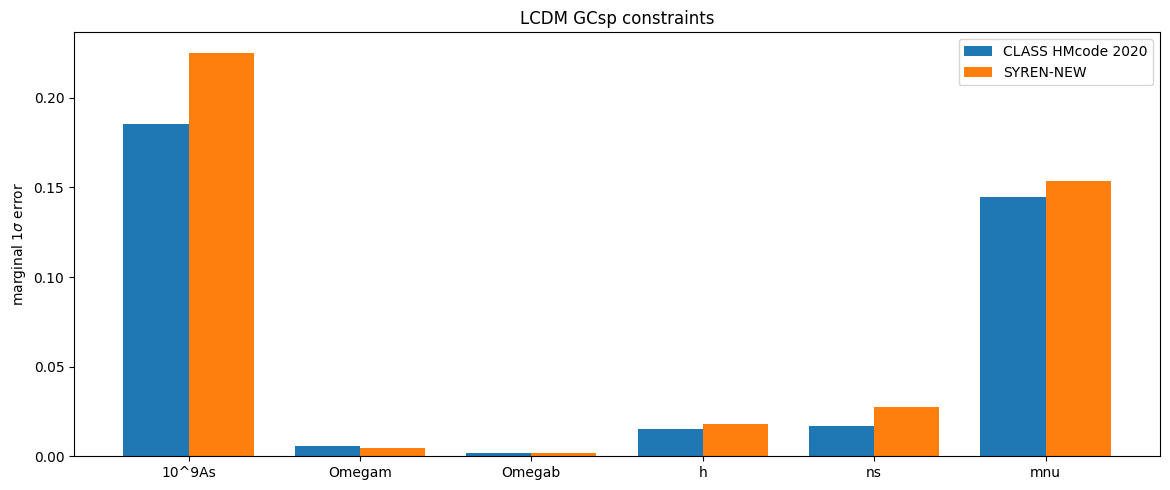

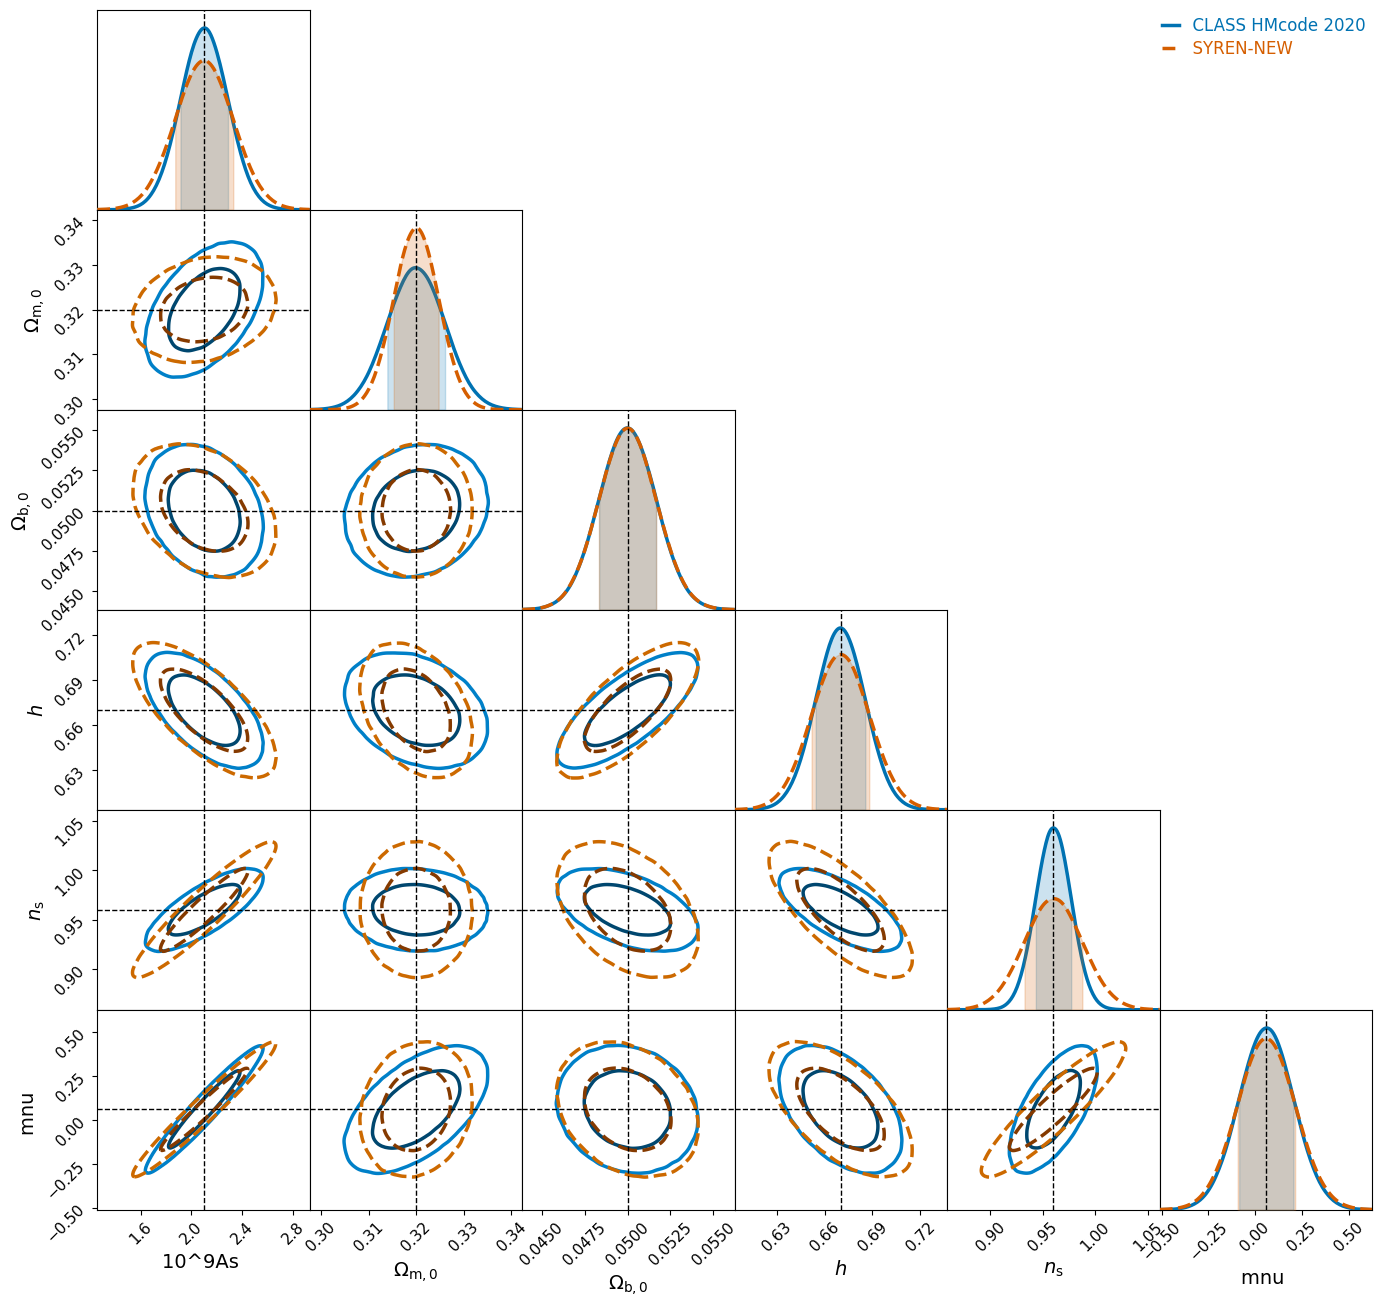

In [8]:
from cosmicfishpie.analysis import fishconsumer
from cosmicfishpie.analysis import fisher_matrix as fisher_matrix_analysis


def plot_fisher_pair(fisher_runs, fiducial, freepars, cosmo_model):
    labels = list(fisher_runs)
    fishers = [fisher_matrix_analysis.fisher_matrix(file_name=str(fisher_runs[label]['file_name'])) for label in labels]
    parameters = list(freepars)
    errors = np.array([fisher.get_confidence_bounds() for fisher in fishers])
    parameter_indices = [[fisher.get_param_names().index(parameter) for parameter in parameters] for fisher in fishers]
    selected_errors = np.array([row[index] for row, index in zip(errors, parameter_indices)])

    plot_dir = results_dir / 'plots'
    plot_dir.mkdir(parents=True, exist_ok=True)
    x = np.arange(len(parameters))
    fig, ax = plt.subplots(figsize=(1.3 * len(parameters) + 4, 5))
    width = 0.38
    for index, (label, values) in enumerate(zip(labels, selected_errors)):
        ax.bar(x + (index - 0.5) * width, values, width, label=label)
    ax.set(xticks=x, xticklabels=parameters, ylabel=r'marginal $1\sigma$ error', title=f'{cosmo_model} GCsp constraints')
    ax.legend()
    fig.tight_layout()
    error_plot = plot_dir / f'{cosmo_model}_minimal_matched_marginal_errors.pdf'
    fig.savefig(error_plot)

    contour_plot = plot_dir / f'{cosmo_model}_minimal_matched_contours.pdf'
    fishconsumer.make_triangle_plot(
        fishers=fishers,
        fisher_labels=labels,
        params=parameters,
        colors=['#0072B2', '#D55E00'],
        truth_values={parameter: fiducial[parameter] for parameter in parameters},
        shade_fisher=[False, False],
        ls_fisher=['-', '--'],
        legend_kwargs={'fontsize': 12, 'loc': 'upper right'},
        label_font_size=14,
        tick_font_size=11,
        savefile=contour_plot,
    )
    return {'marginal_errors': error_plot, 'contours': contour_plot}


plot_fisher_pair(lcdm_fisher_runs, FIDUCIAL_LCDM, LCDM_FREEPARS, 'LCDM')
# plot_fisher_pair(w0wa_fisher_runs, FIDUCIAL_W0WA, W0WA_FREEPARS, 'w0waCDM')

## Interpretation order

Inspect direct linear responses first, then nonlinear responses, then the Fisher contours. A persistent `Omegab`-`10^9As` discrepancy after the matched-profile run should be diagnosed from the response panels and background/growth paths; it should not be attributed to the amplitude conversion without that evidence.